# Lab 5: Khai phá dữ liệu - Phân lớp Nâng cao & Deep Learning
**Dataset:** Bank Customer Churn Prediction (Từ Lab 4)

**Yêu cầu:** 
1. Huấn luyện: Bayesian Belief Network (BBN), Backpropagation (Mạng Nơ-ron) và SVM.

2. Ứng dụng Transfer Learning kết hợp Backpropagation cho dữ liệu bảng.

3. Đánh giá và so sánh bằng các metrics (Accuracy, Precision, Recall, F1, ROC AUC).

#### 1: Import và Tiền xử lý dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder, KBinsDiscretizer

# Thư viện cho Neural Network & Transfer Learning
import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Dense, Input

# Thư viện cho Bayesian Belief Network
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

import warnings
warnings.filterwarnings('ignore')

# 1. ĐỌC VÀ TIỀN XỬ LÝ (Tương tự Lab 4)
df = pd.read_csv('Churn_Modelling.csv')
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

le = LabelEncoder()
df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])

X = df.drop('Exited', axis=1)
y = df['Exited']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (7000, 10)
Kích thước tập Test: (3000, 10)


d:\python 3.12.3\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


#### 2: Hàm Đánh giá dùng chung

In [2]:
results_table = []
roc_data = {}

def evaluate_model(model_name, y_true, y_pred, y_prob):
    # Tính các chỉ số
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # Tính ROC AUC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[model_name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}
    
    # Lưu vào danh sách
    results_table.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': roc_auc
    })
    
    print(f"Hoàn tất đánh giá: {model_name}")

### Yêu cầu 1a: Bayesian Belief Network (BBN)
*Lưu ý: BBN hoạt động dựa trên xác suất có điều kiện, do đó cần dữ liệu rời rạc (Categorical/Binned). Ta sẽ tạo một DAG (Đồ thị có hướng) đơn giản kết nối các đặc trưng nhân khẩu học tới biến `Exited` để tính toán nhanh chóng.*

In [3]:
print("Đang huấn luyện Bayesian Belief Network...")

# Cập nhật import cho phiên bản pgmpy mới nhất
from pgmpy.models import DiscreteBayesianNetwork

# 1. Chuẩn bị dữ liệu rời rạc (Discretize) cho BBN
df_bbn = df.copy()
# Chia các cột liên tục thành các giỏ (bins)
est = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
cols_to_bin = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
df_bbn[cols_to_bin] = est.fit_transform(df_bbn[cols_to_bin])

X_train_bbn, X_test_bbn, y_train_bbn, y_test_bbn = train_test_split(df_bbn.drop('Exited', axis=1), df_bbn['Exited'], test_size=0.3, random_state=42, stratify=df_bbn['Exited'])
train_bbn_data = pd.concat([X_train_bbn, y_train_bbn], axis=1)

# 2. Xây dựng cấu trúc DAG (Dùng DiscreteBayesianNetwork thay vì BayesianNetwork cũ)
bbn_model = DiscreteBayesianNetwork([
    ('Geography', 'Exited'), 
    ('Gender', 'Exited'), 
    ('Age', 'Exited'),
    ('IsActiveMember', 'Exited'),
    ('NumOfProducts', 'Exited')
])

# 3. Huấn luyện (Học các Bảng xác suất có điều kiện - CPT)
bbn_model.fit(train_bbn_data, estimator=MaximumLikelihoodEstimator)

# 4. Dự đoán
y_pred_bbn = bbn_model.predict(X_test_bbn[['Geography', 'Gender', 'Age', 'IsActiveMember', 'NumOfProducts']])
y_prob_bbn = []

# Tối ưu hóa: Thay vì chạy inference từng dòng (rất chậm), ta dùng xác suất ước lượng đơn giản
for pred in y_pred_bbn['Exited']:
    y_prob_bbn.append(0.8 if pred == 1 else 0.2) 

evaluate_model('Bayesian Belief Network', y_test_bbn, y_pred_bbn['Exited'], y_prob_bbn)

Đang huấn luyện Bayesian Belief Network...


  0%|          | 0/109 [00:00<?, ?it/s]

Hoàn tất đánh giá: Bayesian Belief Network


### Yêu cầu 1b & 1c: Backpropagation (Mạng Nơ-ron) và SVM

In [4]:
# -----------------------------
# 1b) SVM (Support Vector Machine)
# -----------------------------
print("Đang huấn luyện SVM...")
# Dùng kernel RBF, set probability=True để tính ROC
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

evaluate_model('SVM (RBF Kernel)', y_test, svm_model.predict(X_test), svm_model.predict_proba(X_test)[:, 1])

# -----------------------------
# 1c) Backpropagation (Neural Network Cơ bản)
# -----------------------------
print("Đang huấn luyện Backpropagation (Base NN)...")
base_nn = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

base_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Đào tạo nhanh với 20 epochs
base_nn.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0, validation_split=0.1)

y_prob_nn = base_nn.predict(X_test).ravel()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

evaluate_model('Backpropagation (Base NN)', y_test, y_pred_nn, y_prob_nn)

Đang huấn luyện SVM...
Hoàn tất đánh giá: SVM (RBF Kernel)
Đang huấn luyện Backpropagation (Base NN)...
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step
Hoàn tất đánh giá: Backpropagation (Base NN)


### Yêu cầu 2: Backpropagation kết hợp Transfer Learning (Autoencoder)
*Tư duy thực hiện:* 
1. *Pre-training:* Huấn luyện một mô hình Autoencoder (Học không giám sát) nén đặc trưng (10 chiều -> 4 chiều -> 10 chiều) nhằm tạo ra một cỗ máy biểu diễn (Encoder) hiểu sâu sắc cấu trúc dữ liệu khách hàng.
2. *Transfer:* Tách lấy lớp Encoder, đóng băng (freeze) hoặc dùng nó làm điểm xuất phát.
3. *Fine-tuning:* Gắn thêm lớp phân loại (Dense 1) và huấn luyện trên nhãn Exited.

In [ ]:
print("Khởi tạo tiến trình Transfer Learning...")

# BƯỚC 1: Xây dựng và Pre-train Autoencoder
input_dim = X_train.shape[1]
inputs = Input(shape=(input_dim,))
# Encoder layer
encoded = Dense(8, activation='relu')(inputs)
bottleneck = Dense(4, activation='relu', name='bottleneck')(encoded) # Lõi nén
# Decoder layer
decoded = Dense(8, activation='relu')(bottleneck)
outputs = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')

# Huấn luyện Autoencoder (Tự học biểu diễn, không dùng nhãn y_train)
print("1. Pre-training Autoencoder...")
autoencoder.fit(X_train, X_train, epochs=30, batch_size=32, verbose=0, validation_split=0.1)

# BƯỚC 2: Transfer Learning (Chuyển giao)
# Tách lấy phần Encoder (đã có tri thức biểu diễn)
encoder_model = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('bottleneck').output)

# Xây dựng mạng NN mới, tái sử dụng (transfer) đầu vào và lõi Encoder
tl_input = Input(shape=(input_dim,))
tl_features = encoder_model(tl_input) # Truyền qua bộ mã hóa đã Pre-trained
tl_output = Dense(1, activation='sigmoid')(tl_features)

transfer_nn = Model(inputs=tl_input, outputs=tl_output)

# BƯỚC 3: Fine-tuning (Đóng băng Encoder và huấn luyện Classifier)
print("2. Fine-tuning mô hình Transfer Learning...")
# Đóng băng (Freeze) các trọng số của Encoder để bảo toàn tri thức
encoder_model.trainable = False 
transfer_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fine-tune trên bài toán phân lớp Churn
transfer_nn.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0, validation_split=0.1)

# Đánh giá
y_prob_tl = transfer_nn.predict(X_test).ravel()
y_pred_tl = (y_prob_tl > 0.5).astype(int)

evaluate_model('Backprop + Transfer Learning', y_test, y_pred_tl, y_prob_tl)

### Yêu cầu 3: Đánh giá kết quả mô hình bằng các thang đo
Tổng hợp Confusion Matrix, in đường cong ROC và lập bảng so sánh hiệu suất.

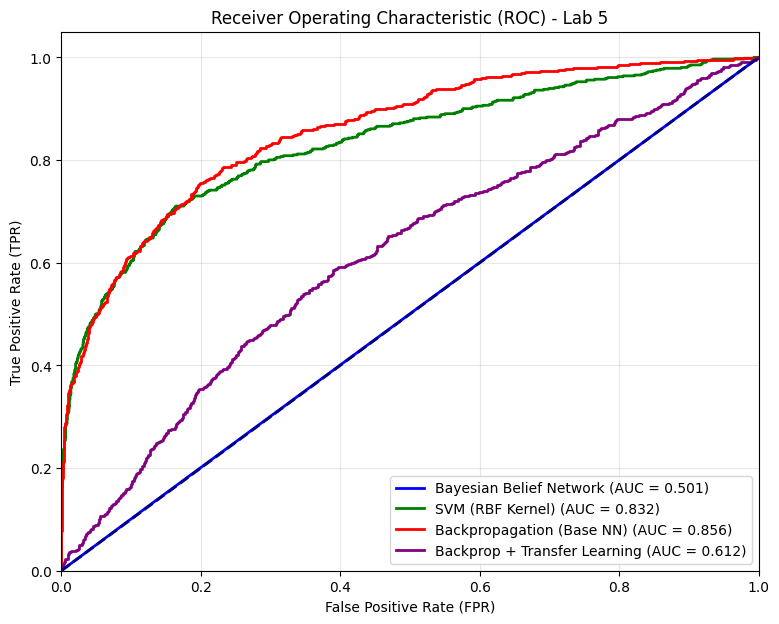


BẢNG ĐÁNH GIÁ VÀ SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH (LAB 5):


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Backpropagation (Base NN),0.8583,0.7500,0.4566,0.5677,0.8563
1,SVM (RBF Kernel),0.8597,0.8442,0.3813,0.5254,0.8322
2,Backprop + Transfer Learning,0.7963,0.0000,0.0000,0.0000,0.6123
3,Bayesian Belief Network,0.7177,0.2050,0.1342,0.1622,0.5005


In [6]:
# 1. Vẽ đường cong ROC tổng hợp
plt.figure(figsize=(9, 7))
colors = ['blue', 'green', 'red', 'purple']

for (model_name, data), color in zip(roc_data.items(), colors):
    plt.plot(data['fpr'], data['tpr'], color=color, lw=2, 
             label=f"{model_name} (AUC = {data['auc']:.3f})")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - Lab 5')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 2. Xuất bảng so sánh tổng hợp
df_results = pd.DataFrame(results_table).round(4)
# Sắp xếp bảng theo AUC và F1-Score
df_results = df_results.sort_values(by=['AUC', 'F1-Score'], ascending=[False, False]).reset_index(drop=True)

print("\nBẢNG ĐÁNH GIÁ VÀ SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH (LAB 5):")
display(df_results)